In [1]:
%load_ext autoreload
%autoreload 2

In [92]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec
from sklearn.gaussian_process.kernels import RBF

from rewards import sample_children_with_corr
from agent import social_generalization, social_generalization_icm, value_shaping

In [3]:
seed = 42
rng: np.random.Generator = np.random.default_rng(seed)

In [4]:
rho_child_child = 0.6
_, child_maps = sample_children_with_corr(
            rng=rng,
            n_children=4,
            length_scale=2.0,
            rho_parent_child=rho_child_child,
            rho_child_child=rho_child_child,
            tol=0.1,
            max_tries=1000,
            grid_size=11
        )

In [5]:
X = np.arange(11)
rewards_1 = child_maps[0].mean(axis=1)
rewards_1 =  (rewards_1 - rewards_1.min()) / (rewards_1.max() - rewards_1.min())
rewards_2 = child_maps[1].mean(axis=1)
rewards_2 = (rewards_2 - rewards_2.min()) / (rewards_2.max() - rewards_2.min())

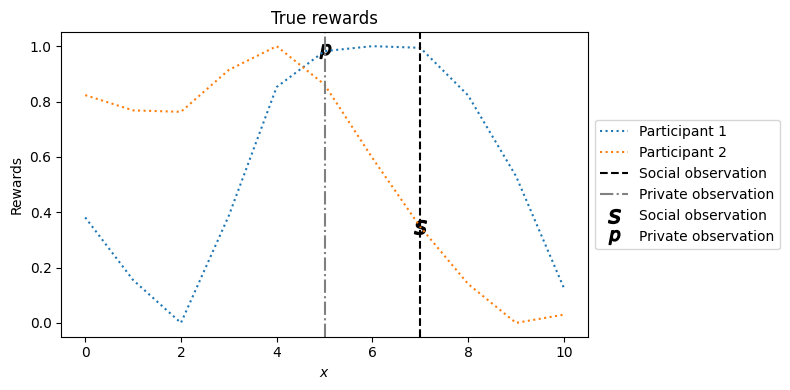

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, rewards_1, label="Participant 1", linestyle="dotted")
ax.plot(X, rewards_2, label="Participant 2", linestyle="dotted")

social_observations_X = 7
social_observations_y = rewards_2[social_observations_X]

private_observations_X = 5
private_observations_y = rewards_1[private_observations_X]

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.scatter(
    social_observations_X, social_observations_y, 
    label="Social observation", marker="$s$", color="k", s=100
)
ax.scatter(
    private_observations_X, private_observations_y, 
    label="Private observation", marker="$p$", color="k", s=100
)

ax.set_xlabel("$x$")
ax.set_ylabel("Rewards")
ax.set_title("True rewards")


ax.legend(
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

### SG model

In [7]:
soc_noise_mult = [1, 100, 1000, 10_000]
sg_preditions = []
for s_n in soc_noise_mult:
    prediction = social_generalization(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale=2.0,
        observation_noise_private=0.001,
        observation_noise_social=0.001 * s_n,
        beta=0.5,
        tau=1,
        random_state=rng.__getstate__()
    )
    sg_preditions.append(prediction)

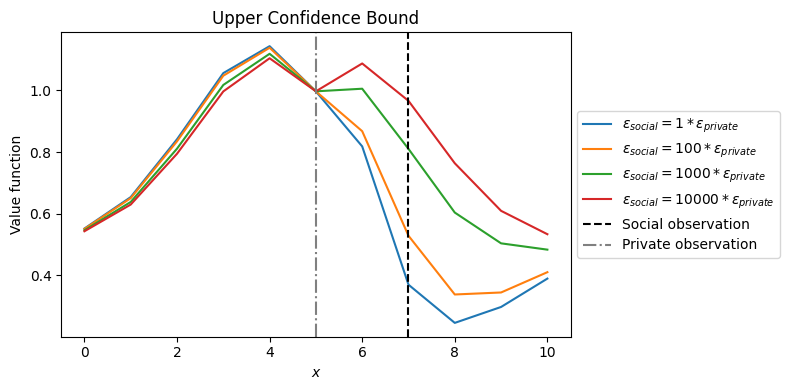

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, s_n in enumerate(soc_noise_mult):
    ax.plot(X, np.log(sg_preditions[i]), label=fr"$\epsilon_{{social}}={s_n}*\epsilon_{{private}}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

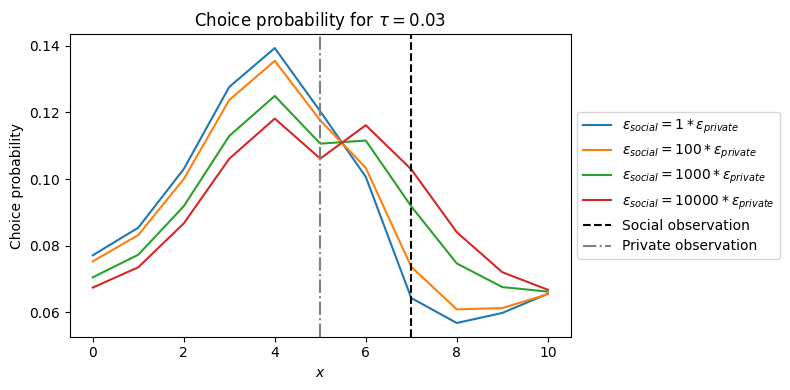

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, s_n in enumerate(soc_noise_mult):
    prob = sg_preditions[i]
    prob /= prob.sum() 
    # prob /= prob.max()
    ax.plot(X, prob, label=fr"$\epsilon_{{social}}={s_n}*\epsilon_{{private}}$")

ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

## ICM model

In [11]:
rhos = [0, 0.5, 0.75, 1]
icm_preditions = []
for rho in rhos[::-1]:
    prediction = social_generalization_icm(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale_private=2.0,
        length_scale_social=2.0,
        observation_noise_private=0.001,
        observation_noise_social=0.001,
        rho=rho,
        beta=0.5,
        tau=1,
        random_state=rng.__getstate__()
    )
    icm_preditions.append(prediction)

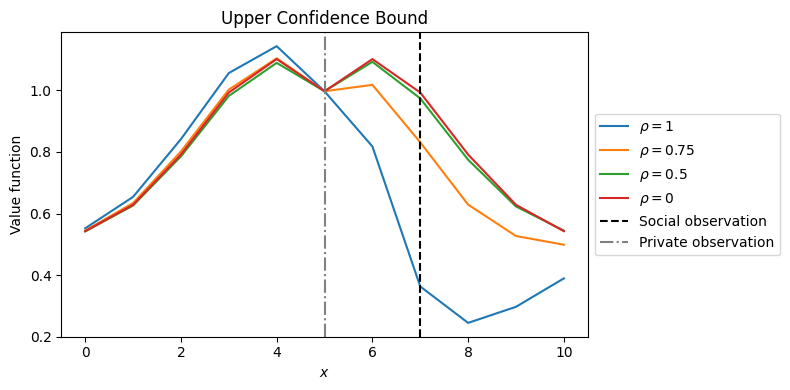

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, rho in enumerate(rhos[::-1]):
    ax.plot(X, np.log(icm_preditions[i]), label=fr"$\rho={rho}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

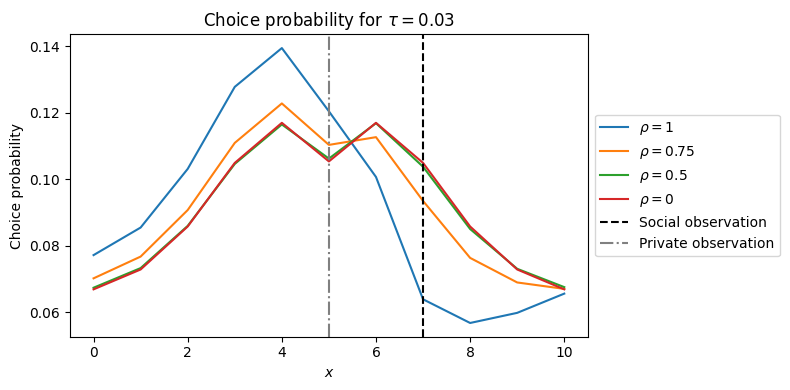

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, rho in enumerate(rhos[::-1]):
    prob = icm_preditions[i]
    # prob /= prob.max()
    prob /= prob.sum() 
    ax.plot(X, prob, label=fr"$\rho={rho}$")


ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

## $\alpha$ Value Shaping

In [22]:
alphas = [0, 0.25, 0.5, 0.75, 1]
value_shaping_preditions = []
for alpha in alphas[::-1]:
    prediction = value_shaping(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale_private=2.0,
        length_scale_social=2.0,
        observation_noise_private=0.001,
        observation_noise_social=0.001,
        alpha=alpha,
        beta_private=0.5,
        beta_social=0.5,
        tau=1,
        random_state=rng.__getstate__(),
        value_shaping_type="F"
    )
    # prediction /= prediction.max()
    value_shaping_preditions.append(prediction)

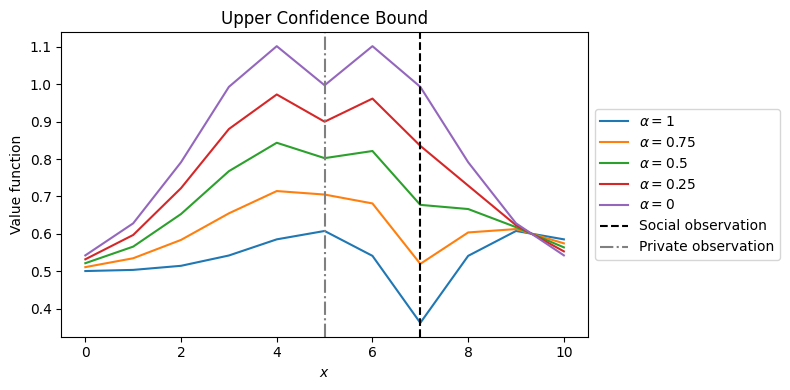

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    ax.plot(X, np.log(value_shaping_preditions[i]), label=fr"$\alpha={alpha}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

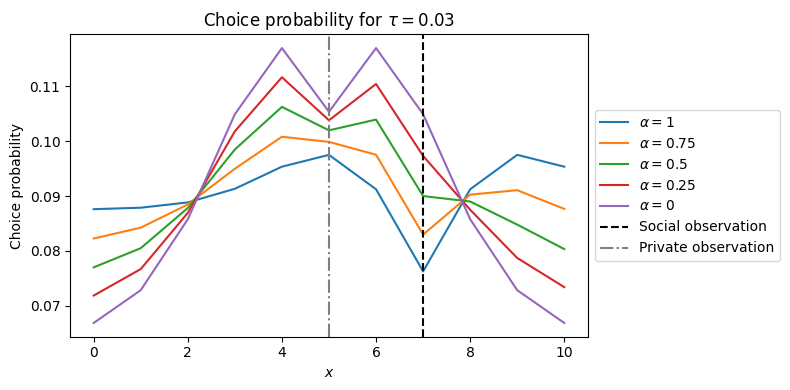

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    prob = value_shaping_preditions[i]
    # prob /= prob.max()
    prob /= prob.sum() 
    ax.plot(X, prob, label=fr"$\alpha={alpha}$")


ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

## Correlated Kalman Value Shaping

In [25]:
alphas = [0, 0.25, 0.5, 0.75, 1]
value_shaping_preditions_ck = []
for alpha in alphas[::-1]:
    prediction = value_shaping(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale_private=2.0,
        length_scale_social=2.0,
        observation_noise_private=0.001,
        observation_noise_social=0.001,
        alpha=alpha,
        beta_private=0.5,
        beta_social=0.5,
        tau=1,
        random_state=rng.__getstate__(),
        value_shaping_type="CK"
    )
    # prediction /= prediction.max()
    value_shaping_preditions_ck.append(prediction)

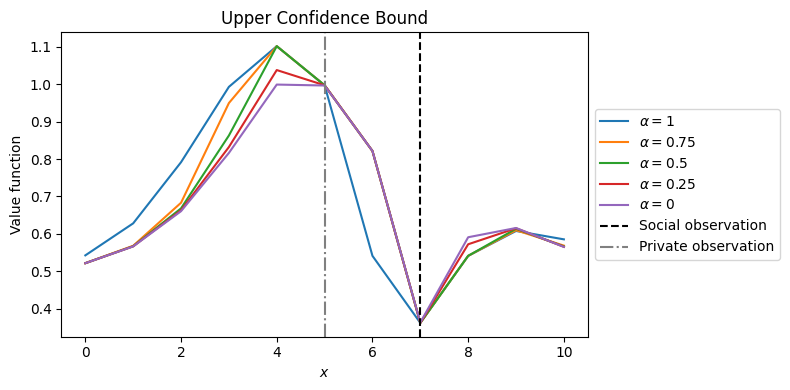

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    ax.plot(X, np.log(value_shaping_preditions_ck[i]), label=fr"$\alpha={alpha}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

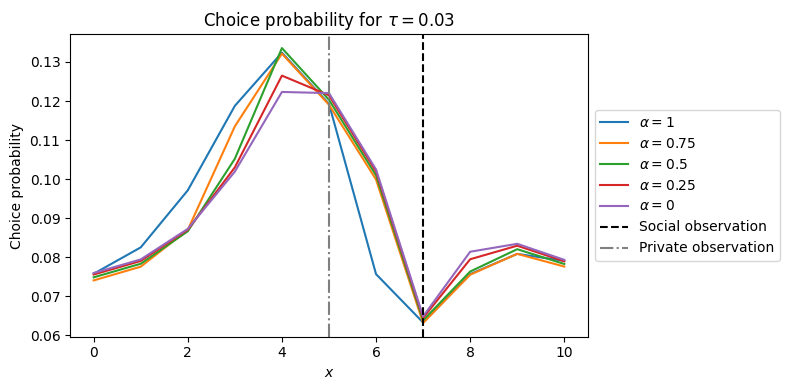

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    prob = value_shaping_preditions_ck[i]
    # prob /= prob.max()
    prob /= prob.sum() 
    ax.plot(X, prob, label=fr"$\alpha={alpha}$")


ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

## Figure 1

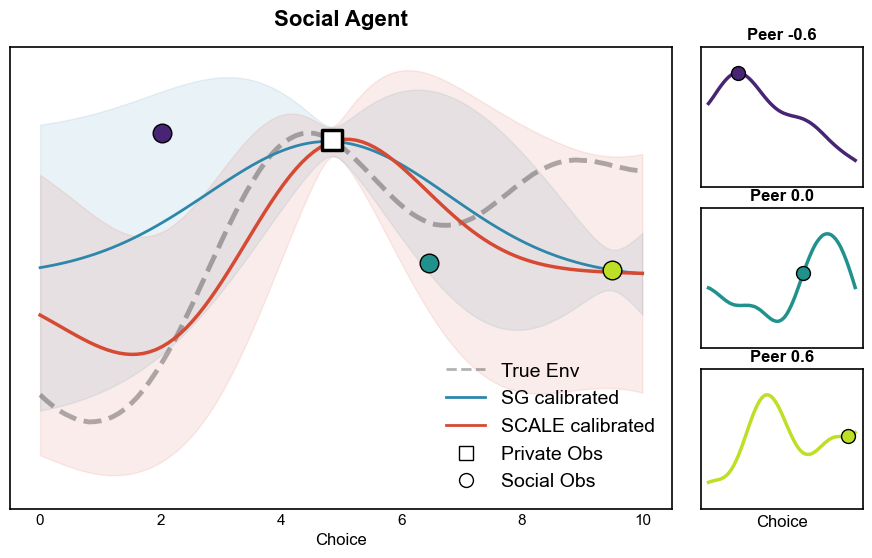

In [129]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

def rbf_kernel(x1, x2, length_scale=1.0, sigma_f=1.0):
    if x1.ndim == 1: x1 = x1[:, None]
    if x2.ndim == 1: x2 = x2[:, None]
    kernel = RBF(length_scale=length_scale)
    return sigma_f**2 * kernel(x1, x2)

def generate_environments(seed=42):
    rng = np.random.default_rng(seed)
    X = np.linspace(0, 10, 100).reshape(-1, 1)

    length_scale = 2.0
    K = rbf_kernel(X, X, length_scale=length_scale)
    L = np.linalg.cholesky(K + 1e-6 * np.eye(len(X)))

    # 1. Generate Base Independent Components
    z_focal = rng.standard_normal(len(X))
    z_indep_1 = rng.standard_normal(len(X))
    z_indep_2 = rng.standard_normal(len(X))
    z_indep_3 = rng.standard_normal(len(X))

    # 2. Standardized Functions (Mean 0, Var 1)
    f_focal_std = L @ z_focal
    f_indep_1 = L @ z_indep_1
    f_indep_2 = L @ z_indep_2
    f_indep_3 = L @ z_indep_3

    # 3. Mixing & Normalization Helper
    def normalize_centered(arr):
        # Scale to range approx [-0.5, 0.5]
        # We assume arr is roughly N(0, 1), so range is roughly [-2, 2]
        # We perform min-max normalization to [-0.5, 0.5]
        min_val, max_val = arr.min(), arr.max()
        return (arr - min_val) / (max_val - min_val) - 0.5

    f_focal = normalize_centered(f_focal_std)

    # 4. Peer Generation
    correlations = [-0.6, 0.0, 0.6]
    peer_curves = []

    # Peer 1: Negative (-0.6)
    f_peer_neg_std = -0.6 * f_focal_std + np.sqrt(1 - 0.6**2) * f_indep_1
    peer_curves.append(normalize_centered(f_peer_neg_std))

    # Peer 2: Uncorrelated (0.0)
    # Pure independent noise
    peer_curves.append(normalize_centered(f_indep_2))

    # Peer 3: Positive (0.6)
    f_peer_pos_std = 0.6 * f_focal_std + np.sqrt(1 - 0.6**2) * f_indep_3
    peer_curves.append(normalize_centered(f_peer_pos_std))

    return X, f_focal, peer_curves, correlations

def create_figure_1(env_seed=53, np_seed=71):
    X, f_focal, peer_curves, corrs = generate_environments(seed=env_seed)
    rng = np.random.default_rng(np_seed)

    fig = plt.figure(figsize=(11, 6))
    gs = gridspec.GridSpec(3, 4, wspace=0.15, hspace=0.15, width_ratios=[1, 1, 1, 0.8])

    cmap = plt.get_cmap('viridis')
    peer_colors = [cmap(0.1), cmap(0.5), cmap(0.9)]

    peer_obs_data = []

    # Lists to store inputs for social models: list of arrays (one array per peer)
    X_obs_social_list = []
    y_obs_social_list = []

    # --- 1. Plot Peers (Right Column) ---
    for i, (rho, f_peer, color) in enumerate(zip(corrs, peer_curves, peer_colors)):
        ax = plt.subplot(gs[i, 3])
        ax.plot(X, f_peer, color=color, lw=2.5)

        domain_mask = np.ones_like(X.flatten(), dtype=bool)
        if i == 0: # Negative
            domain_mask = (X.flatten() > 1.0) & (X.flatten() < 3.5)
        elif i == 1: # Zero
            domain_mask = (X.flatten() > 4.0) & (X.flatten() < 6.5)
        else: # Positive
            domain_mask = (X.flatten() > 7.0) & (X.flatten() < 9.5)
        # Find High Value in the assigned zone
        masked_f = f_peer.flatten()
        # Set values outside domain to -inf so argmax picks best within domain
        masked_f[~domain_mask] = -np.inf
        # Select top 1 indices
        indices = np.argsort(masked_f)[-1:]

        # indices = rng.choice(np.arange(100), size=3, replace=False)

        # Temp lists for this specific peer
        this_peer_X = []
        this_peer_y = []

        for idx in indices:
            x_val = X[idx][0]
            y_val = f_peer[idx]

            ax.scatter(x_val, y_val, s=100, facecolors=color, edgecolors='k', zorder=10, marker='o')
            # Store flat for main plotting
            peer_obs_data.append((x_val, y_val, rho, color))

            this_peer_X.append([x_val])
            this_peer_y.append([y_val])

        # Store arrays for model input
        X_obs_social_list.append(np.array(this_peer_X))
        y_obs_social_list.append(np.array(this_peer_y))

        ax.set_title(f"Peer {rho}", fontsize=12, fontweight='bold', pad=5)
        ax.set_ylim(-0.8, 0.8)
        ax.set_yticks([])
        ax.set_xticks([])
        if i == 2: ax.set_xlabel("Choice", fontsize=12)

    # Prepare Data
    idx_f = rng.integers(20, 80)
    x_priv = X[idx_f][0]
    y_priv = f_focal[idx_f]

    full_rho_list = [1.0] + corrs

    # SG Call
    _, mu_sg, std_sg = social_generalization(
        X_obs_private=np.array([[x_priv]]),
        y_obs_private=np.array([[y_priv]]),
        X_obs_social=X_obs_social_list,
        y_obs_social=y_obs_social_list,
        X_predict=X,
        length_scale=2.0,
        observation_noise_private=0.01,
        observation_noise_social=[20, 20, 0.01],
        beta=0.0, tau=1.0, random_state=rng.__getstate__(),
        return_predict=True
    )

    # SCALE Call
    _, mean_list, std_list = social_generalization_icm(
        X_obs_private=np.array([[x_priv]]),
        y_obs_private=np.array([[y_priv]]),
        X_obs_social=X_obs_social_list,
        y_obs_social=y_obs_social_list,
        X_predict=X,
        length_scale_private=1.5, length_scale_social=1.5,
        observation_noise_private=0.01, observation_noise_social=0.01,
        rho=full_rho_list,
        beta=0.0, tau=1.0, random_state=rng.__getstate__(),
        return_full_predictions=True
    )
    mu_scale = np.array(mean_list[0])
    std_scale = np.array(std_list[0])


    # Compute Variance locally for visualization (Confidence bands)
    X_all_obs = np.vstack([np.array([[x_priv]])] + [np.array([[d[0]]]) for d in peer_obs_data])

    # --- 3. Plot Social Agent (Left Panel) ---
    ax_main = plt.subplot(gs[:, :3])

    ax_main.plot(X, f_focal, color='black', ls='--', lw=3.5, label="True Environment", alpha=0.3)

    # Plot SG
    ax_main.plot(X, mu_sg, color='#2E86AB', lw=2, ls='-', label="SG Prediction")
    scale_std = 2
    ax_main.fill_between(X.flatten(), mu_sg.flatten() - std_sg / scale_std, mu_sg.flatten() + std_sg / scale_std, color='#2E86AB', alpha=0.1)

    # Plot SCALE
    ax_main.plot(X, mu_scale, color='#D64933', lw=2.5, ls='-', label="SCALE Prediction")
    ax_main.fill_between(X.flatten(), mu_scale.flatten() - std_scale / scale_std, mu_scale.flatten() + std_scale / scale_std, color='#D64933', alpha=0.1)

    # Observations
    ax_main.scatter(x_priv, y_priv, s=200, facecolors='white', edgecolors='black', linewidth=2.5, zorder=15, marker='s', label="Private Obs")
    for (px, py, _, pcolor) in peer_obs_data:
        ax_main.scatter(px, py, s=180, facecolors=pcolor, edgecolors='k', zorder=10, marker='o')

    ax_main.set_title("Social Agent", fontsize=16, fontweight='bold', pad=15)
    ax_main.set_ylim(-0.8, 0.8)
    ax_main.set_yticks([])
    ax_main.set_xlabel("Choice", fontsize=12)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', ls='--', lw=2, alpha=0.3, label='True Env'),
        Line2D([0], [0], color='#2E86AB', lw=2, ls='-', label='SG calibrated'),
        Line2D([0], [0], color='#D64933', lw=2, ls='-', label='SCALE calibrated'),
        Line2D([0], [0], marker='s', color='w', markeredgecolor='black', markerfacecolor='white', markersize=10, label='Private Obs'),
        Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor='white', markersize=10, label='Social Obs'),
    ]
    ax_main.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=14, ncol=1)  # , bbox_to_anchor=(0.95, 1.0),

    # ax_main.text(-0.05, 1.02, 'a', transform=ax_main.transAxes, fontsize=16, fontweight='bold')
    # plt.gcf().get_axes()[0].text(-0.15, 1.1, 'b', transform=plt.gcf().get_axes()[0].transAxes, fontsize=16, fontweight='bold')

    plt.savefig('scale_model_illustration.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('scale_model_illustration.png', dpi=300, bbox_inches='tight')
    plt.savefig('scale_model_illustration.svg', dpi=300, bbox_inches='tight')

for i in [15]:
    create_figure_1(i, np_seed=4242)